In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
test_df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/filtered1_test_data.csv")

In [ ]:
train_df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/filtered1_train_data.csv")

In [ ]:
import re
import nltk
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download stopwords if not already downloaded
nltk.download('stopwords')

def preprocess_text(text):
    """Cleans text by lowercasing, removing stopwords, and applying stemming."""
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))

    # Convert to lowercase
    text = text.lower()

    # Remove non-alphabetic characters (keep spaces)
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize and remove stopwords, apply stemming
    words = text.split()
    words = [ps.stem(word) for word in words if word not in stop_words]

    # Join words back into a string
    return " ".join(words)

train_df = train_df.copy()
test_df = test_df.copy()

# ✅ Use .loc to assign new column safely
train_df.loc[:, 'cleaned_text'] = train_df['tweet_text'].apply(preprocess_text)
test_df.loc[:, 'cleaned_text'] = test_df['tweet_text'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
train_df

,tweet_text,cyberbullying_type,cleaned_text
0,@Questionnier is dis a joke gay rape or babe rape,cyberbullying,questionni di joke gay rape babe rape
1,@cushen19 so when you get out of school you'll...,not_cyberbullying,cushen get school youll alreadi outdat dejavu
2,The smell of delusion is in the air. Just bc y...,cyberbullying,smell delus air bc feel type way doesnt make t...
3,RT @nickfalkner: I dededeconstructed my tart s...,not_cyberbullying,rt nickfalkn dededeconstruct tart jam lemon co...
4,Oh my god.,not_cyberbullying,oh god
...,...,...,...
12758,@GlobalCalgary Notice how seating of women and...,not_cyberbullying,globalcalgari notic seat women men seper one s...
12759,"as of now, favorite teams on #MKR would have t...",not_cyberbullying,favorit team mkr would eva amp debra amp steve...
12760,females like roseanne barr and those 2 hideous...,cyberbullying,femal like roseann barr hideou bitch call char...
12761,RT @RavenHUWolf: University of #Texas-#Arlingt...,not_cyberbullying,rt ravenhuwolf univers texasarlington muslim s...


In [ ]:
label_mapping = {
    "not_cyberbullying": 0,
    "cyberbullying":1,
}


# Apply mapping
train_df["cyberbullying_encoded_type"] = train_df["cyberbullying_type"].map(label_mapping)
test_df["cyberbullying_encoded_type"] = test_df["cyberbullying_type"].map(label_mapping)


In [ ]:
X_train, X_val, y_train, y_val = train_df['cleaned_text'],test_df['cleaned_text'],train_df['cyberbullying_encoded_type'],test_df['cyberbullying_encoded_type']

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
max_len = 35
oov_token = '00_V'
padding_type = 'post'
trunc_type = 'post'

tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
vocab_size = len(tokenizer.word_index) + 1
print("Vocab Size: ",vocab_size)

Vocab Size:  21770


In [ ]:
train_sequences = tokenizer.texts_to_sequences(X_train)
X_train = pad_sequences(train_sequences, maxlen=max_len, padding=padding_type, truncating=trunc_type)

val_sequences = tokenizer.texts_to_sequences(X_val)
X_val = pad_sequences(val_sequences, maxlen=max_len, padding=padding_type, truncating=trunc_type)

In [ ]:
from tensorflow.keras import layers, Sequential
import tensorflow as tf

# ------------------------------
# Transformer Encoder Layer
# ------------------------------
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, heads, neurons, dropout_rate=0.3):
        super(TransformerEncoder, self).__init__()
        self.embed_dim = embed_dim
        self.heads = heads
        self.neurons = neurons
        self.dropout_rate = dropout_rate

        # Multi-head self-attention
        self.att = layers.MultiHeadAttention(num_heads=heads, key_dim=embed_dim)

        # Feed-forward network
        self.ffn = Sequential([
            layers.Dense(neurons, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(embed_dim),
        ])

        # Normalization and dropout
        self.layernorm1 = layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(dropout_rate)
        self.dropout2 = layers.Dropout(dropout_rate)

    def call(self, inputs, training=None):
        # Self-attention + residual
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        # Feed-forward + residual
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)


# ------------------------------
# Token + Position Embedding Layer
# ------------------------------
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, maxlen, vocab_size, embed_dim):
        super(TokenAndPositionEmbedding, self).__init__()
        self.maxlen = maxlen
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

        self.token_emb = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.pos_emb = layers.Embedding(input_dim=maxlen, output_dim=embed_dim)

    def call(self, x):
        maxlen = tf.shape(x)[-1]
        positions = tf.range(start=0, limit=maxlen, delta=1)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions

In [ ]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras import regularizers
from tensorflow.keras import layers, regularizers, Model, Sequential
import tensorflow as tf


In [ ]:
# Hyperparams
embed_dim = 50
heads = 2
neurons = 16   # smaller feed-forward size (less complexity)
maxlen = 35
vocab_size = 23178

# Model definition
inputs = layers.Input(shape=(maxlen,))
embedding_layer = TokenAndPositionEmbedding(maxlen, vocab_size, embed_dim)
x = embedding_layer(inputs)
transformer_block = TransformerEncoder(embed_dim, heads, neurons)
x = transformer_block(x)
x = layers.GlobalAveragePooling1D()(x)
x = Dropout(0.35)(x)
# ⚡ Output for binary classification
outputs = layers.Dense(
    1, activation="sigmoid",  # single neuron with sigmoid
    kernel_regularizer=regularizers.l1_l2(l1=1e-6, l2=1e-6)
)(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile for binary classification
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 35)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, 35, 50)         │     1,160,650 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 35, 50)         │        22,216 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 50)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,182,917 (4.51 MB)

 Trainable params: 1,182,917 (4.51 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

In [ ]:
checkpoint = ModelCheckpoint(
    "Transformarf_binary_model.h5",
    monitor="val_loss",
    mode="min",
    save_best_only=True,
    verbose=1
)

"""earlystopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)
"""
lr_reduction = ReduceLROnPlateau(
    monitor="val_loss",
    patience=2,
    factor=0.5,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
history = model.fit(X_train,y_train,
                    validation_data=(X_val,y_val),
                    epochs=25,
                    batch_size=32,
                    callbacks=[checkpoint, lr_reduction])

Epoch 1/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6761 - loss: 0.5920
Epoch 1: val_loss improved from inf to 0.37017, saving model to Transformarf_binary_model.h5


399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.6762 - loss: 0.5918 - val_accuracy: 0.8482 - val_loss: 0.3702 - learning_rate: 1.0000e-04
Epoch 2/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8600 - loss: 0.3393
Epoch 2: val_loss improved from 0.37017 to 0.27142, saving model to Transformarf_binary_model.h5


399/399 ━━━━━━━━━━━━━━━━━━━━ 17s 42ms/step - accuracy: 0.8601 - loss: 0.3393 - val_accuracy: 0.8862 - val_loss: 0.2714 - learning_rate: 1.0000e-04
Epoch 3/25
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9186 - loss: 0.2082
Epoch 3: val_loss improved from 0.27142 to 0.23322, saving model to Transformarf_binary_model.h5


399/399 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - accuracy: 0.9186 - loss: 0.2082 - val_accuracy: 0.9030 - val_loss: 0.2332 - learning_rate: 1.0000e-04
Epoch 4/25
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9467 - loss: 0.1480
Epoch 4: val_loss did not improve from 0.23322
399/399 ━━━━━━━━━━━━━━━━━━━━ 18s 44ms/step - accuracy: 0.9466 - loss: 0.1480 - val_accuracy: 0.9106 - val_loss: 0.2336 - learning_rate: 1.0000e-04
Epoch 5/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9524 - loss: 0.1303
Epoch 5: val_loss improved from 0.23322 to 0.22481, saving model to Transformarf_binary_model.h5


399/399 ━━━━━━━━━━━━━━━━━━━━ 21s 45ms/step - accuracy: 0.9523 - loss: 0.1303 - val_accuracy: 0.9198 - val_loss: 0.2248 - learning_rate: 1.0000e-04
Epoch 6/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9659 - loss: 0.1002
Epoch 6: val_loss did not improve from 0.22481
399/399 ━━━━━━━━━━━━━━━━━━━━ 22s 55ms/step - accuracy: 0.9659 - loss: 0.1002 - val_accuracy: 0.9065 - val_loss: 0.3167 - learning_rate: 1.0000e-04
Epoch 7/25
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9719 - loss: 0.0841
Epoch 7: val_loss did not improve from 0.22481

Epoch 7: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
399/399 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.9719 - loss: 0.0840 - val_accuracy: 0.9141 - val_loss: 0.2967 - learning_rate: 1.0000e-04
Epoch 8/25
398/399 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9801 - loss: 0.0598
Epoch 8: val_loss did not improve from 0.22481
399/399 ━━━━━━━━━━━━━━━━━━━━ 24s 51ms/step - accuracy: 0.9801 - loss: 0.0598 - v

In [ ]:
from matplotlib import pyplot as plt

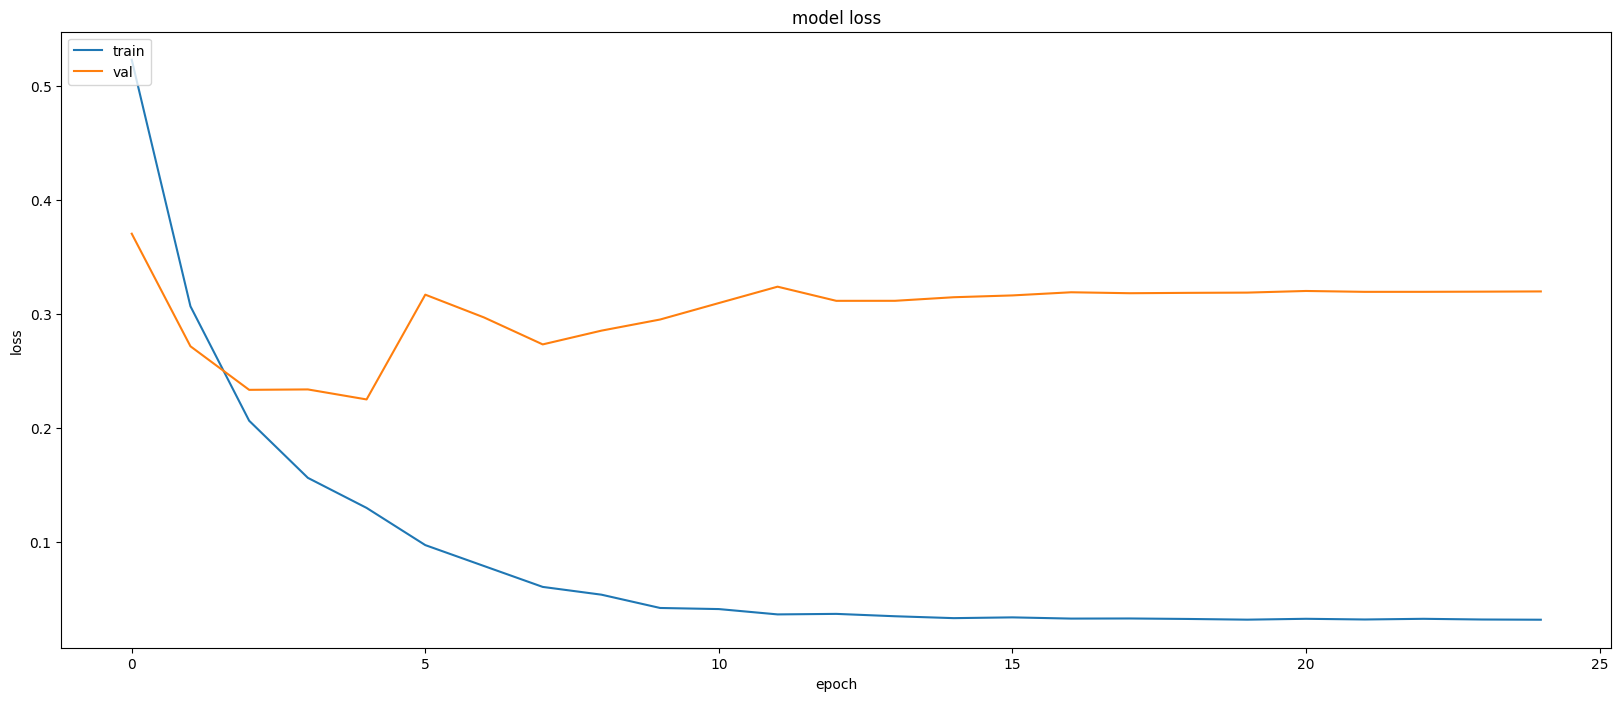

In [ ]:
plt.figure(figsize=(20,8))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

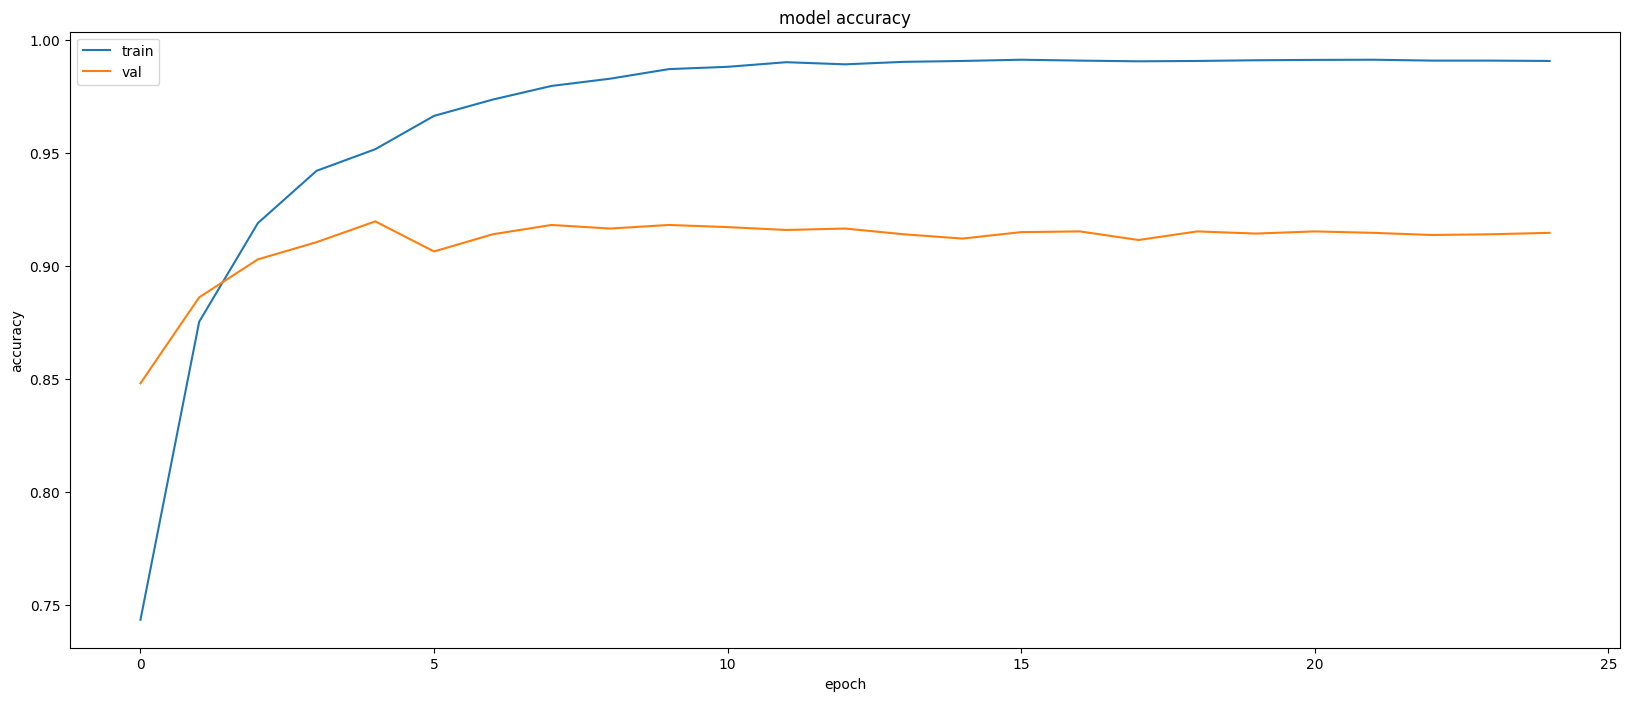

In [ ]:
plt.figure(figsize=(20,8))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

99/99 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step


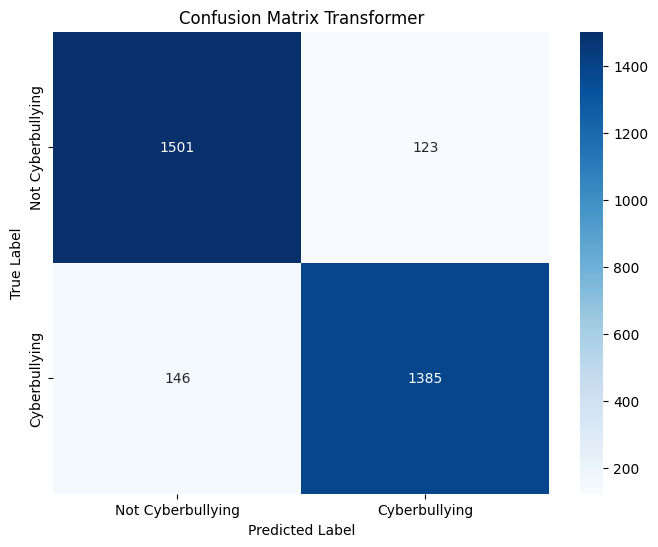

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

# Make predictions on the validation set
y_pred_prob = model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int) # Convert probabilities to binary class labels

# Calculate the confusion matrix
cm = confusion_matrix(y_val, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Cyberbullying', 'Cyberbullying'], yticklabels=['Not Cyberbullying', 'Cyberbullying'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Transformer')
plt.show()

In [ ]:
from sklearn.metrics import classification_report as cr
print(cr(y_val, y_pred))


              precision    recall  f1-score   support

           0       0.91      0.92      0.92      1624
           1       0.92      0.90      0.91      1531

    accuracy                           0.91      3155
   macro avg       0.91      0.91      0.91      3155
weighted avg       0.91      0.91      0.91      3155

